# Group138 – LLM Assignment 2B
## Retrieval-Augmented Generation (RAG) Pipeline

**Team:** Group 138  
**Course:** AIMLCZG536 – Large Language Models  
**Dependency:** Assignment 1B (QLoRA fine-tuned model + domain corpus)

### RAG Flow
```
Corpus → Cleaning → Chunking → Embeddings → FAISS / BM25 → Hybrid RRF
       → Cross-Encoder Re-ranking → Prompt → LLM → Evaluation → Tabular RAG
``` 

## GROUP - 138

### Team Members


1. **MADIWALE MAYURESH NITIN**  
   2024ac05420@wilp.bits-pilani.ac.in

2. **AREPU PAVAN KUMAR**  
   2024ac05700@wilp.bits-pilani.ac.in

2. **CHENDRA SHEKAR G**  
   2024ac05502@wilp.bits-pilani.ac.in

4. **VIVAN SANJAY ATHREYA**  
   2024ac05492@wilp.bits-pilani.ac.in


## Phase 0 – Setup & Imports

In [ ]:
# Install dependencies (run once)
# !pip install -r ../requirements.txt --quiet

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

CORPUS_DIR = ROOT / 'data' / 'corpus'
INDEX_DIR  = ROOT / 'indexes'
EVAL_DIR   = ROOT / 'evaluation'
OUTPUT_DIR = ROOT / 'outputs'

for d in [INDEX_DIR, EVAL_DIR, OUTPUT_DIR]:
    d.mkdir(exist_ok=True)

print('Paths OK')
print(f'Corpus: {CORPUS_DIR}')

Paths OK
Corpus: /Users/pavankumararepu/BitsPilani/2nd Year/AIMLCZG536_LLM/Assignment/Assignment_Solution/Group138_LLM_Assignment_2B/data/corpus


## Phase 2 – Document Loading

In [2]:
from src.utils import load_documents, clean_documents

documents = load_documents(CORPUS_DIR)
print(f'\nLoaded {len(documents)} documents')
for doc in documents:
    print(f"  [{doc['doc_id']}] {doc['title'][:70]}  ({len(doc['text'].split())} words)")

[utils] Loaded 10 documents from '/Users/pavankumararepu/BitsPilani/2nd Year/AIMLCZG536_LLM/Assignment/Assignment_Solution/Group138_LLM_Assignment_2B/data/corpus'

Loaded 10 documents
  [0] A Review of Bangla Natural Language Processing Tasks and the Utility o  (23128 words)
  [1] A Survey on Transformer Compression  (19448 words)
  [2] A dissemination workshop for introducing young Italian students to NLP  (1621 words)
  [3] Deep Transfer Learning Beyond Transformer Language Models in Informati  (32311 words)
  [4] Defining a New NLP Playground  (14208 words)
  [5] How do language models learn facts Dynamics curricula and hallucinatio  (17076 words)
  [6] Natural Language Processing 4 All NLP4All A New Online Platform for Te  (3288 words)
  [7] Teaching NLP with Bracelets and Restaurant Menus An Interactive Worksh  (6624 words)
  [8] Transformers The End of History for NLP  (6921 words)
  [9] TurkicNLP An NLP Toolkit for Turkic Languages  (16230 words)


## Phase 3 – Cleaning

In [4]:
clean_docs = clean_documents(documents)

# Quick before/after comparison
print('=== Before ===')
print(documents[3]['text'][:400])
print('\n=== After ===')
print(clean_docs[3]['text'][:400])

[utils] Cleaned 10 documents
=== Before ===
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
Deep Transfer Learning & Beyond: Transformer Language Models in 
Information Systems Research 
Deep Transfer Learning & Beyond 
Transformer Language Models in Information Systems Research 
Ross Gruetzemacher 
Wichita State University, W. Frank Barton School of Business, ross.gruetzemacher@wichita.edu 
David Paradice 
Auburn University, Harbert College of Business,

=== After ===
Deep Transfer Learning & Beyond: Transformer Language Models in 
Information Systems Research 
Deep Transfer Learning & Beyond 
Transformer Language Models in Information Systems Research 
Ross Gruetzemacher 
Wichita State University, W. Frank Barton School of Business, ross.gruetzemacher@wichita.edu 
David Paradice 
Auburn University, Harbert College of Business, dparadice@auburn.edu 
AI is widel


## Phase 4 – Chunking Strategy Comparison

In [5]:
from src.chunking import compare_strategies

best_chunks, chunking_report = compare_strategies(clean_docs)

# Save report
with open(EVAL_DIR / 'chunking_report.json', 'w') as f:
    json.dump(chunking_report, f, indent=2)

# Display as DataFrame
df_chunk = pd.DataFrame(chunking_report).T
display(df_chunk)

[chunking] fixed_chunking → 312 chunks
[chunking] sliding_window_chunking → 2183 chunks
[chunking] semantic_chunking → 294 chunks
[chunking] Best strategy: 'semantic'
  fixed: {'num_chunks': 312, 'avg_chunk_words': 490.6, 'std_chunk_words': 54.8, 'broken_sentence_pct': 73.4}
  sliding_window: {'num_chunks': 2183, 'avg_chunk_words': 125.5, 'std_chunk_words': 97.9, 'broken_sentence_pct': 34.08}
  semantic: {'num_chunks': 294, 'avg_chunk_words': 469.3, 'std_chunk_words': 249.9, 'broken_sentence_pct': 31.29} ← SELECTED


,num_chunks,avg_chunk_words,std_chunk_words,broken_sentence_pct
fixed,312.0,490.6,54.8,73.40
sliding_window,2183.0,125.5,97.9,34.08
semantic,294.0,469.3,249.9,31.29


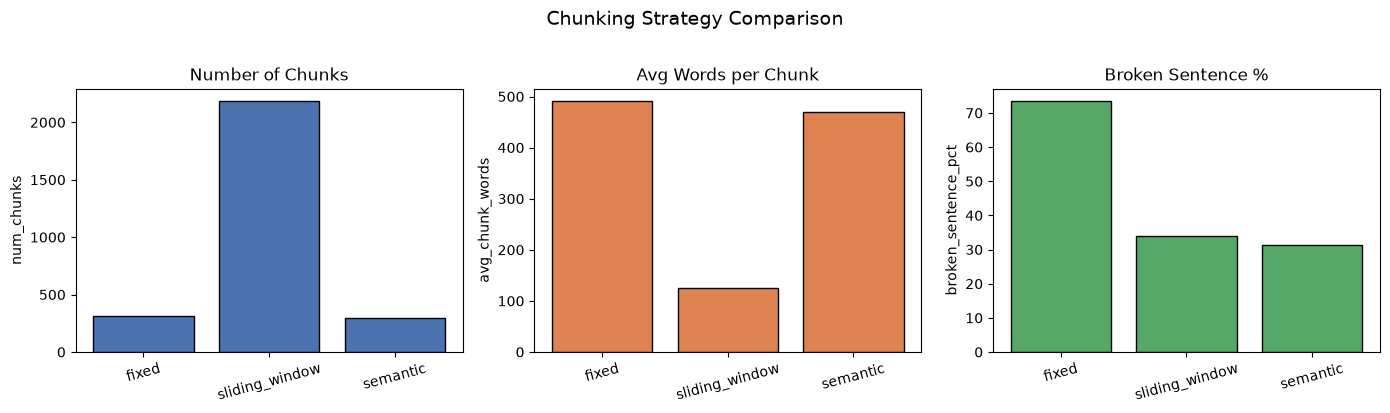

In [6]:
# Visualise chunking strategy metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics   = ['num_chunks', 'avg_chunk_words', 'broken_sentence_pct']
titles    = ['Number of Chunks', 'Avg Words per Chunk', 'Broken Sentence %']
strategies = list(chunking_report.keys())
colours   = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, title, colour in zip(axes, metrics, titles, colours):
    values = [chunking_report[s][metric] for s in strategies]
    ax.bar(strategies, values, color=colour, edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Chunking Strategy Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chunking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 5 – Embeddings

In [7]:
from src.embeddings import EmbeddingModel

embed_model = EmbeddingModel('all-MiniLM-L6-v2')
embeddings  = embed_model.embed_chunks(best_chunks)

print(f'Embedding matrix: {embeddings.shape}')
print(f'dtype: {embeddings.dtype}')

# Save for later
np.save(INDEX_DIR / 'embeddings.npy', embeddings)

/Users/pavankumararepu/BitsPilani/2nd Year/AIMLCZG536_LLM/Assignment/Assignment_Solution/Group138_LLM_Assignment_2B/.venv/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


[embeddings] Loading model 'all-MiniLM-L6-v2' …


/Users/pavankumararepu/BitsPilani/2nd Year/AIMLCZG536_LLM/Assignment/Assignment_Solution/Group138_LLM_Assignment_2B/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[embeddings] Model loaded. Embedding dim = 384
[embeddings] Encoding 294 chunks …


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

[embeddings] Done. Shape: (294, 384)
Embedding matrix: (294, 384)
dtype: float32


## Phase 6 – Dense Retrieval (FAISS)

In [8]:
from src.retrieval import FAISSRetriever

faiss_ret = FAISSRetriever()
faiss_ret.build(best_chunks, embeddings)
faiss_ret.save(INDEX_DIR / 'faiss')

# Quick smoke test
test_q = 'What are transformer models?'
q_emb  = embed_model.embed_query(test_q)
results = faiss_ret.search(q_emb, top_k=3)
print(f'\nTop-3 FAISS results for: "{test_q}"')
for chunk, score in results:
    print(f'  [{score:.4f}] {chunk["title"][:60]}')

[retrieval] FAISS index built with 294 vectors (dim=384)
[retrieval] FAISS index saved to '/Users/pavankumararepu/BitsPilani/2nd Year/AIMLCZG536_LLM/Assignment/Assignment_Solution/Group138_LLM_Assignment_2B/indexes/faiss'

Top-3 FAISS results for: "What are transformer models?"
  [0.4890] A Survey on Transformer Compression
  [0.4809] A Survey on Transformer Compression
  [0.4493] Deep Transfer Learning Beyond Transformer Language Models in


## Phase 7 – Sparse Retrieval (BM25)

In [9]:
from src.retrieval import BM25Retriever

bm25_ret = BM25Retriever()
bm25_ret.build(best_chunks)
bm25_ret.save(INDEX_DIR / 'bm25')

results_bm25 = bm25_ret.search(test_q, top_k=3)
print(f'\nTop-3 BM25 results for: "{test_q}"')
for chunk, score in results_bm25:
    print(f'  [{score:.4f}] {chunk["title"][:60]}')

[retrieval] BM25 index built over 294 chunks
[retrieval] BM25 index saved to '/Users/pavankumararepu/BitsPilani/2nd Year/AIMLCZG536_LLM/Assignment/Assignment_Solution/Group138_LLM_Assignment_2B/indexes/bm25'

Top-3 BM25 results for: "What are transformer models?"
  [7.6670] A Survey on Transformer Compression
  [7.2813] Transformers The End of History for NLP
  [6.7754] A Review of Bangla Natural Language Processing Tasks and the


## Phase 8 – Hybrid Retrieval (RRF)

In [10]:
from src.retrieval import HybridRetriever

hybrid_ret = HybridRetriever(faiss_ret, bm25_ret, embed_model)
results_hybrid = hybrid_ret.search(test_q, top_k=5)

print(f'\nTop-5 Hybrid (RRF) results for: "{test_q}"')
for chunk, score in results_hybrid:
    print(f'  [rrf={score:.5f}] {chunk["title"][:60]}')


Top-5 Hybrid (RRF) results for: "What are transformer models?"
  [rrf=0.03102] Deep Transfer Learning Beyond Transformer Language Models in
  [rrf=0.03058] A Review of Bangla Natural Language Processing Tasks and the
  [rrf=0.02738] A Survey on Transformer Compression
  [rrf=0.02712] A Survey on Transformer Compression
  [rrf=0.02711] A Survey on Transformer Compression


## Phase 9 – Cross-Encoder Re-ranking

In [11]:
from src.reranker import CrossEncoderReranker

reranker = CrossEncoderReranker()
ranked   = reranker.rerank(test_q, results_hybrid, top_k=5)

# Before vs. after
CrossEncoderReranker.compare(results_hybrid, ranked, n=5)

[reranker] Loading cross-encoder 'cross-encoder/ms-marco-MiniLM-L-6-v2' …
[reranker] Cross-encoder loaded.

BEFORE re-rank                      | AFTER re-rank                      
  1. Deep Transfer Learning Beyond  0.0310 | 1. A Survey on Transformer Compre 4.2406
  2. A Review of Bangla Natural Lan 0.0306 | 2. A Survey on Transformer Compre 3.3205
  3. A Survey on Transformer Compre 0.0274 | 3. Deep Transfer Learning Beyond  2.9808
  4. A Survey on Transformer Compre 0.0271 | 4. A Survey on Transformer Compre 1.7758
  5. A Survey on Transformer Compre 0.0271 | 5. A Review of Bangla Natural Lan 1.3389



## Phase 10 – Prompt Construction

In [12]:
from src.prompt import build_prompt

prompt = build_prompt(test_q, ranked)
print(prompt)

You are a knowledgeable assistant specialising in Natural Language Processing
and related research topics.

Answer the question **only** using the information in the context below.
If the answer is not present in the context, respond with:
"I cannot find a relevant answer in the provided documents."

### Context
[A Survey on Transformer Compression]
CONCEPT OF TRANSFORMER
The Transformer architecture is firstly proposed to tackle tasks
like machine translation [11]. A standard Transformer architecture
contains main blocks, multi-head attention (MHA) and feedforward networks (FFN). The attention is formulated as
Attention(Q, K, V ) = softmax(QKT
√
d
)V,
(1)
where Q, K, V are query, key and value matrix, respectively. d is
the feature’s dimension. The multi-head attention jointly extracts
information from diverse subspaces, which is the concatenation of
different heads,
MultiHead(Q, K, V ) = Concat(head1, ..., headh)W O,
where headi = Attention(QW Q
i , KW K
i , V W V
i ).
(2)
W Q, W K, 

## Phase 11 – LLM Generation

Configure your LLM provider before running the cell below.
- **Ollama (local):** start `ollama serve` and pull a model (`ollama pull llama3`)
- **HuggingFace:** set `LLM_PROVIDER=hf` and `HF_MODEL=...` in your environment

In [14]:
import os, requests

OLLAMA_MODEL = os.getenv('OLLAMA_MODEL', 'llama3')
OLLAMA_URL   = os.getenv('OLLAMA_URL',   'http://localhost:11434')

def llm_ollama(prompt: str) -> str:
    payload = {'model': OLLAMA_MODEL, 'prompt': prompt, 'stream': False}
    try:
        resp = requests.post(f'{OLLAMA_URL}/api/generate', json=payload, timeout=120)
        resp.raise_for_status()
        return resp.json().get('response', '').strip()
    except Exception as e:
        return f'[LLM ERROR] {e}'

# Test
answer = llm_ollama(prompt)
print('Answer:\n', answer)

Answer:
 [LLM ERROR] HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError("HTTPConnection(host='localhost', port=11434): Failed to establish a new connection: [Errno 61] Connection refused"))


## Phase 12 – Evaluation

In [15]:
from src.evaluation import evaluate_rag, answer_coverage

QUESTIONS = [
    'What is the main contribution of transformer models to NLP?',
    'How does QLoRA reduce memory usage during fine-tuning?',
    'What are the challenges of NLP for low-resource languages?',
    'Describe the Bangla NLP tasks covered in the survey.',
    'How is NLP taught interactively to young students?',
]

def rag_fn(question):
    t0 = time.perf_counter()
    candidates = hybrid_ret.search(question, top_k=20)
    ranked_    = reranker.rerank(question, candidates, top_k=5)
    prompt_    = build_prompt(question, ranked_)
    answer_    = llm_ollama(prompt_)
    latency    = time.perf_counter() - t0
    return answer_, [c for c, _ in ranked_], latency

eval_results = evaluate_rag(
    questions=QUESTIONS,
    references=None,
    relevant_doc_ids=None,
    rag_fn=rag_fn,
)

df_eval = pd.DataFrame(eval_results)
display(df_eval[['question', 'latency_s', 'coverage']])

with open(OUTPUT_DIR / 'eval_results.json', 'w') as f:
    json.dump(eval_results, f, indent=2, ensure_ascii=False)
print('Saved → outputs/eval_results.json')


[evaluation] Summary
-------------------------------------------------------
  latency_s            avg=4.5912  min=4.0670  max=4.8640
  coverage             avg=0.0000  min=0.0000  max=0.0000
-------------------------------------------------------



,question,latency_s,coverage
0,What is the main contribution of transformer m...,4.864,0.0
1,How does QLoRA reduce memory usage during fine...,4.067,0.0
2,What are the challenges of NLP for low-resourc...,4.852,0.0
3,Describe the Bangla NLP tasks covered in the s...,4.352,0.0
4,How is NLP taught interactively to young stude...,4.821,0.0


Saved → outputs/eval_results.json


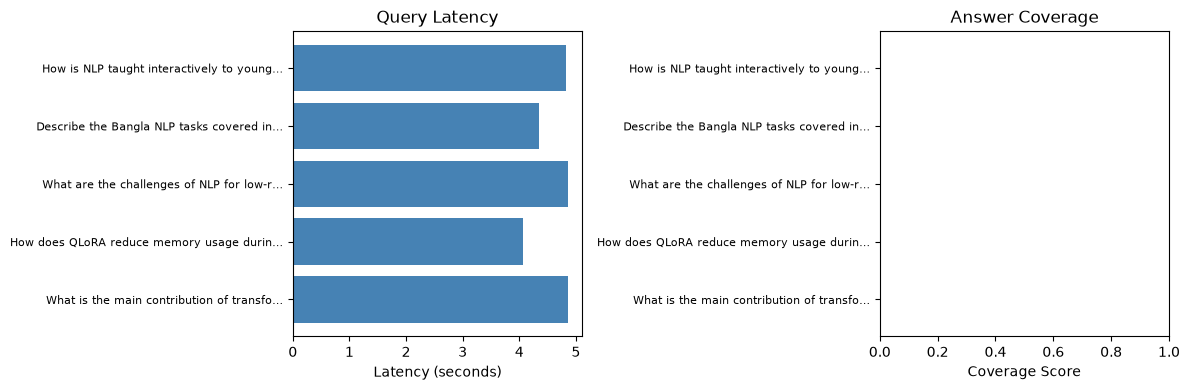

In [16]:
# Visualise latency and coverage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(range(len(QUESTIONS)), df_eval['latency_s'], color='steelblue')
axes[0].set_yticks(range(len(QUESTIONS)))
axes[0].set_yticklabels([q[:40]+'…' for q in QUESTIONS], fontsize=8)
axes[0].set_xlabel('Latency (seconds)')
axes[0].set_title('Query Latency')

axes[1].barh(range(len(QUESTIONS)), df_eval['coverage'], color='darkorange')
axes[1].set_yticks(range(len(QUESTIONS)))
axes[1].set_yticklabels([q[:40]+'…' for q in QUESTIONS], fontsize=8)
axes[1].set_xlabel('Coverage Score')
axes[1].set_title('Answer Coverage')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 13 – Tabular RAG

> **Note:** Tabular RAG requires PDF files with embedded tables.  
> Place your PDFs in `data/pdfs/` and update `PDF_DIR` below.

In [17]:
from src.tabular_rag import TabularRAG

PDF_DIR = ROOT / 'data' / 'pdfs'

tab_rag = TabularRAG(embed_model)

if PDF_DIR.exists() and list(PDF_DIR.glob('*.pdf')):
    table_chunks = tab_rag.extract_tables_from_dir(PDF_DIR)
    if table_chunks:
        tab_rag.build_index(table_chunks)
        q_table = 'What models are compared in the evaluation table?'
        context = tab_rag.answer(q_table, llm_fn=None)   # None = return raw context
        print('Table context:\n', context)
    else:
        print('No table rows extracted from PDFs.')
else:
    print(f'No PDFs found at {PDF_DIR}. Skipping Tabular RAG.')

No PDFs found at /Users/pavankumararepu/BitsPilani/2nd Year/AIMLCZG536_LLM/Assignment/Assignment_Solution/Group138_LLM_Assignment_2B/data/pdfs. Skipping Tabular RAG.


## Summary

| Phase | Component | Status |
|-------|-----------|--------|
| 2 | Document Loading | ✅ |
| 3 | Cleaning | ✅ |
| 4 | Chunking (Fixed / Sliding / Semantic) | ✅ |
| 5 | Embeddings (all-MiniLM-L6-v2) | ✅ |
| 6 | FAISS Dense Index | ✅ |
| 7 | BM25 Sparse Index | ✅ |
| 8 | Hybrid RRF Retrieval | ✅ |
| 9 | Cross-Encoder Re-ranking | ✅ |
| 10 | Prompt Construction | ✅ |
| 11 | LLM Generation (Ollama / HF) | ✅ |
| 12 | Evaluation (Latency, Coverage, ROUGE) | ✅ |
| 13 | Tabular RAG | ✅ |